# Visualiser des paires sketch-image (ChairV2)
Notebook minimal pour afficher des paires depuis `/Data/arthur.buis/pairs-sketch/ChairV2`.

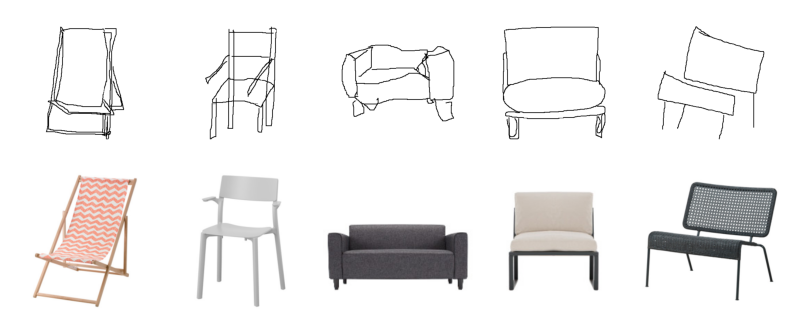

In [3]:

from pathlib import Path
import re
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_root_input = Path('/Data/arthur.buis/pairs-sketch/ChairV2')
num_samples = 5

IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return [p for p in folder.rglob('*') if p.suffix.lower() in IMG_EXTS]

def resolve_dataset_root(dataset_path: Path):
    candidates = [
        dataset_path,
        Path('/data/arthur.buis/pairs-sketch/ChairV2'),
        Path('/users/eleves-b/2023/arthur.buis/Data/arthur.buis/pairs-sketch/ChairV2'),
        Path('/users/eleves-b/2023/arthur.buis/pairs-sketch/ChairV2'),
        Path.cwd() / 'Data/arthur.buis/pairs-sketch/ChairV2',
        Path.cwd() / 'data/arthur.buis/pairs-sketch/ChairV2',
        Path.cwd() / 'pairs-sketch/ChairV2',
    ]
    seen = set()
    uniq_candidates = []
    for c in candidates:
        if str(c) not in seen:
            seen.add(str(c))
            uniq_candidates.append(c)
    for c in uniq_candidates:
        if c.exists():
            return c.resolve(), uniq_candidates
    return None, uniq_candidates

def index_by_rel_stem(base_dir: Path):
    return {str(p.relative_to(base_dir).with_suffix('')): p for p in list_images(base_dir)}

def pair_from_two_dirs(sketch_dir: Path, photo_dir: Path):
    photo_idx = index_by_rel_stem(photo_dir)
    pairs = []
    for sketch_path in list_images(sketch_dir):
        rel_stem = str(sketch_path.relative_to(sketch_dir).with_suffix(''))
        if rel_stem in photo_idx:
            pairs.append((sketch_path, photo_idx[rel_stem]))
        else:
            parent_stem = re.sub(r'_\d+$', '', rel_stem)
            if parent_stem in photo_idx:
                pairs.append((sketch_path, photo_idx[parent_stem]))
    return pairs

def collect_pairs(root: Path):
    all_pairs = []
    for a_name, b_name in [('trainA', 'trainB'), ('testA', 'testB'), ('valA', 'valB'), ('A', 'B'), ('sketch', 'photo'), ('sketches', 'photos')]:
        a_dir, b_dir = root / a_name, root / b_name
        if a_dir.exists() and b_dir.exists():
            all_pairs.extend(pair_from_two_dirs(a_dir, b_dir))
    return all_pairs

dataset_root, tested_paths = resolve_dataset_root(dataset_root_input)
if dataset_root is None:
    for p in tested_paths:
        print(' -', p)
    raise FileNotFoundError('Dataset introuvable.')

pairs = collect_pairs(dataset_root)
if not pairs:
    raise RuntimeError('Aucune paire sketch-image trouvée.')

k = min(num_samples, len(pairs))
samples = random.sample(pairs, k=k)

fig, axes = plt.subplots(2, k, figsize=(2 * k, 4))
axes[0, 0].set_ylabel('Sketch', fontsize=9)
axes[1, 0].set_ylabel('Photo', fontsize=9)

for i, (sketch_path, photo_path) in enumerate(samples):
    axes[0, i].imshow(Image.open(sketch_path).convert('RGB'))
    axes[0, i].axis('off')
    axes[1, i].imshow(Image.open(photo_path).convert('RGB'))
    axes[1, i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()
